# Week 3 Assignment - Customer Intelligence System (Country Segmentation)

Name: Deeptesh Mohapatra

Dataset: Unsupervised Learning on Country Data (Kaggle: rohan0301/unsupervised-learning-on-country-data)

Background: HELP International is an NGO that has raised about 10 million dollars. The CEO
needs to decide which countries are in the most urgent need of aid. My job is to group the
countries using socio-economic and health indicators and then point out the countries the
CEO should focus on.

In this notebook I treat each country like a "customer" of the NGO and build a small customer
intelligence system around it:

1. Load and understand the data
2. EDA to see how the indicators behave
3. Scale the features
4. Cluster the countries with K-Means and DBSCAN (unsupervised)
5. Read the clusters and figure out which group is the neediest
6. Rank the countries that need aid the most
7. Turn the clusters into labels and train classification models (Random Forest and XGBoost)
   so a new country can be assigned to a group automatically
8. Wrap up with recommendations

So the pipeline uses clustering (K-Means, DBSCAN), classification, and ensemble methods
(Random Forest, XGBoost) together on the same data.

## Setup

Importing the libraries I need.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print('All imports OK')

All imports OK


## 1. Loading the data

I download the dataset from Kaggle using kagglehub and read the CSV. The file is cached so
running this again is fast.

In [2]:
import kagglehub
import os, glob

path = kagglehub.dataset_download('rohan0301/unsupervised-learning-on-country-data')
csv_file = [f for f in glob.glob(os.path.join(path, '*.csv')) if 'dict' not in f.lower()][0]
print('CSV file:', os.path.basename(csv_file))

df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

CSV file: Country-data.csv
Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 2. Understanding the data

Each row is one country. The columns are:

- country: name of the country
- child_mort: deaths of children under 5 per 1000 live births
- exports: exports as a percent of GDP per capita
- health: health spending as a percent of GDP per capita
- imports: imports as a percent of GDP per capita
- income: net income per person
- inflation: yearly growth rate of total GDP
- life_expec: life expectancy in years
- total_fer: number of children per woman
- gdpp: GDP per capita

Let me check the types and whether anything is missing.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [5]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Number of countries:', df['country'].nunique())

Missing values: 0
Duplicate rows: 0
Number of countries: 167


The data is clean - 167 countries, 9 numeric indicators, no missing values and no
duplicates. So I do not need any imputation. The indicators are on very different scales
(income and gdpp are in the thousands while health and fertility are single digits), so I
will scale them before clustering.

## 3. Exploratory data analysis

### 3.1 Distribution of each indicator

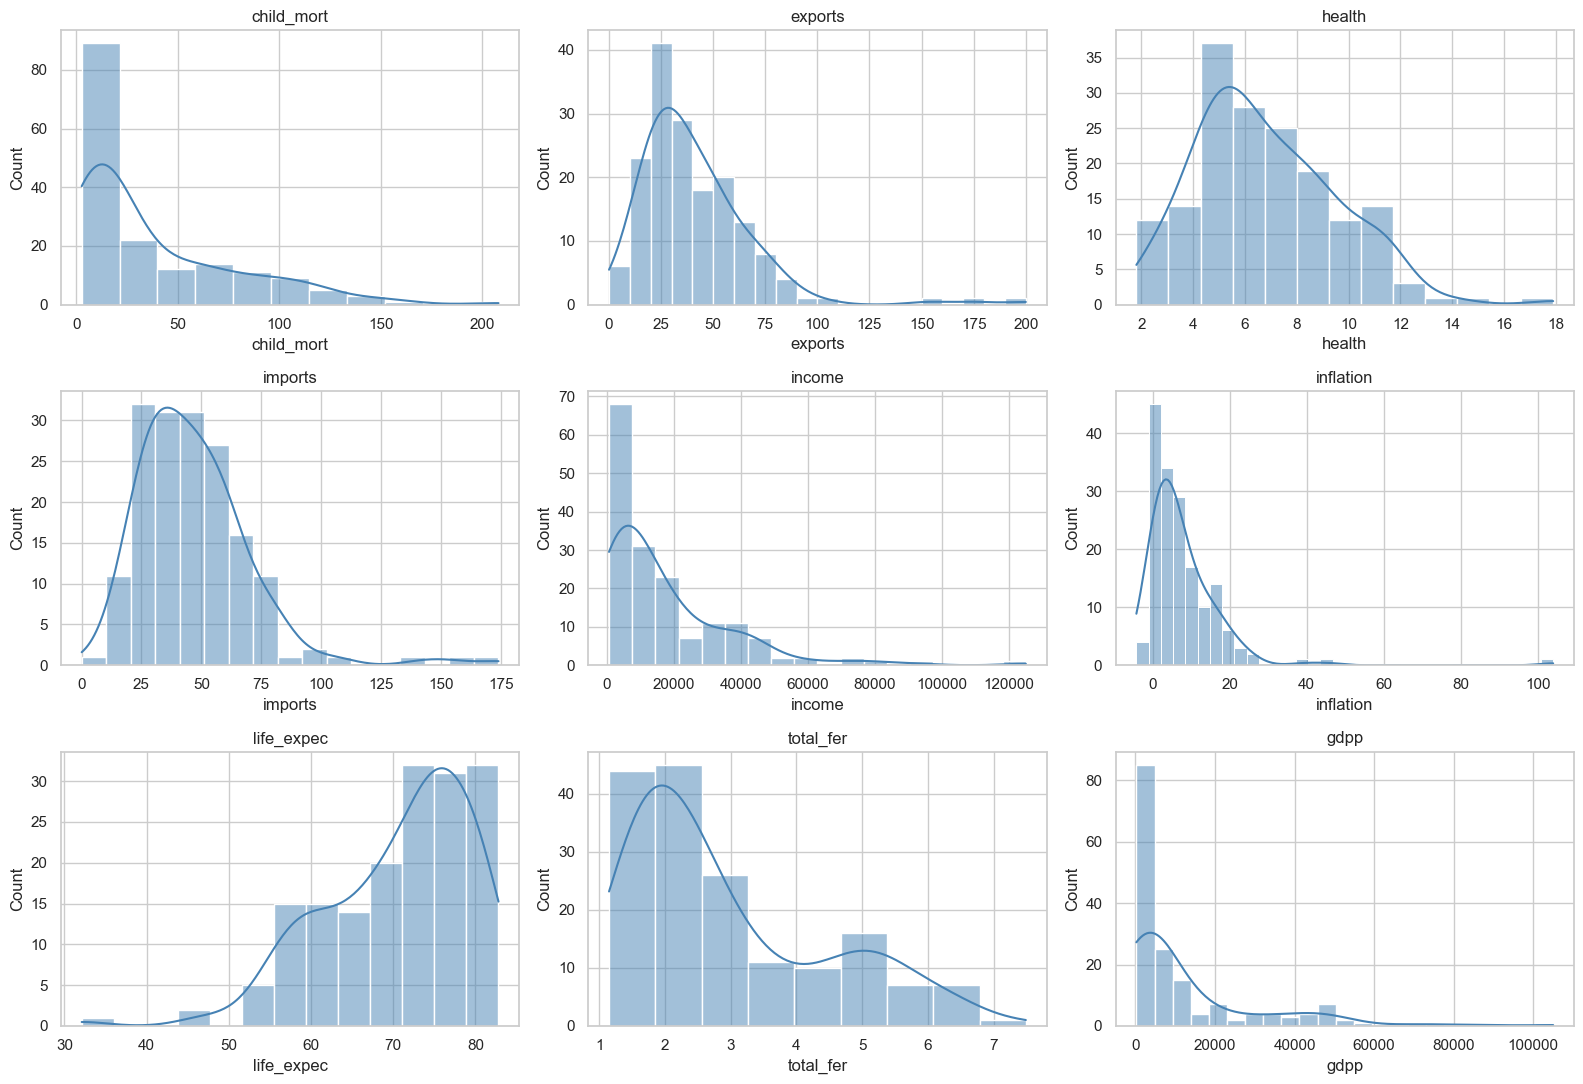

In [6]:
features = ['child_mort','exports','health','imports','income',
            'inflation','life_expec','total_fer','gdpp']
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flat, features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout(); plt.show()

### 3.2 Correlation between indicators

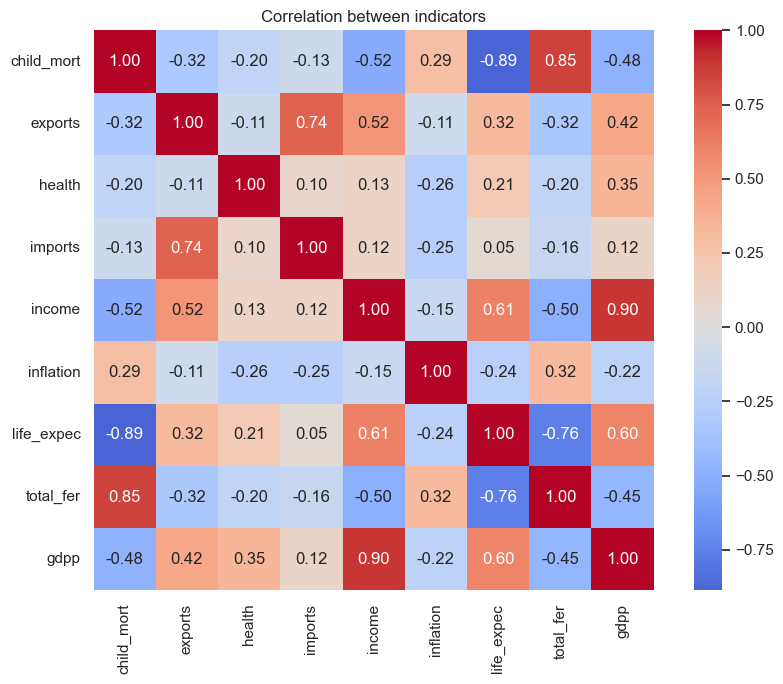

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation between indicators')
plt.tight_layout(); plt.show()

### 3.3 The poorest and richest countries by GDP per capita

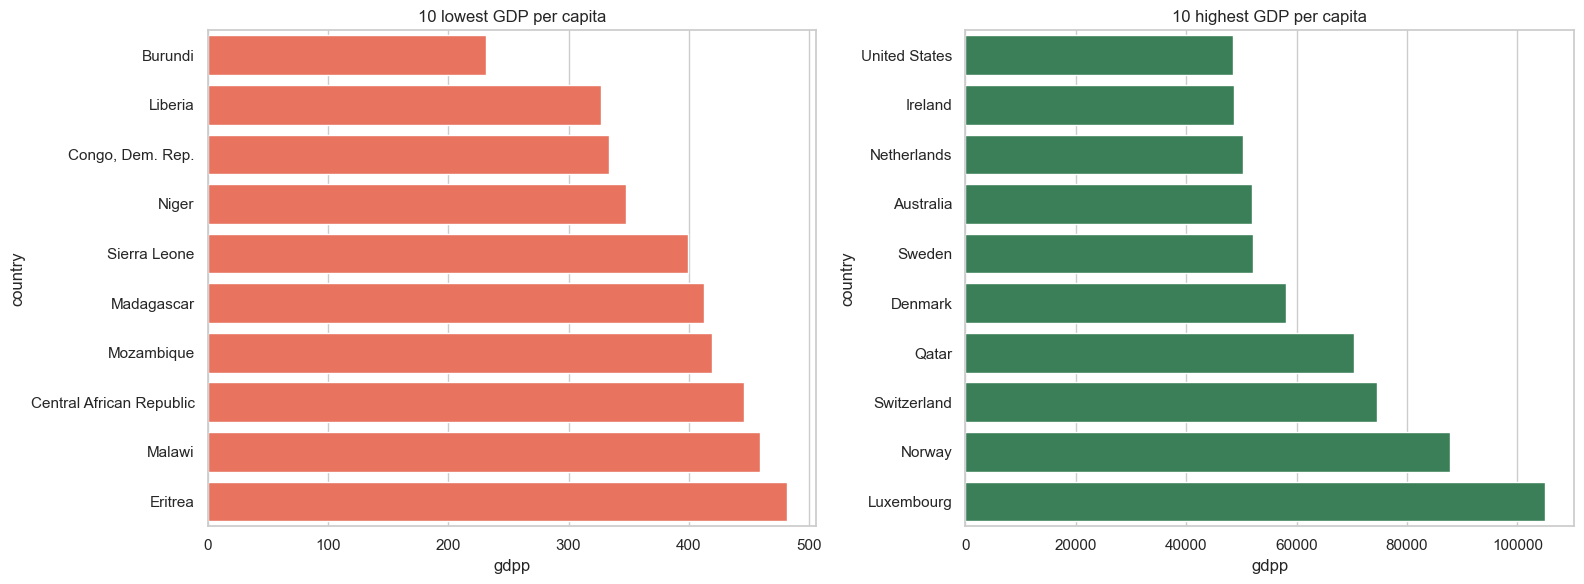

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
low = df.nsmallest(10, 'gdpp')[['country','gdpp']].sort_values('gdpp')
high = df.nlargest(10, 'gdpp')[['country','gdpp']].sort_values('gdpp')
sns.barplot(data=low, x='gdpp', y='country', ax=axes[0], color='tomato')
axes[0].set_title('10 lowest GDP per capita')
sns.barplot(data=high, x='gdpp', y='country', ax=axes[1], color='seagreen')
axes[1].set_title('10 highest GDP per capita')
plt.tight_layout(); plt.show()

### 3.4 Child mortality vs income

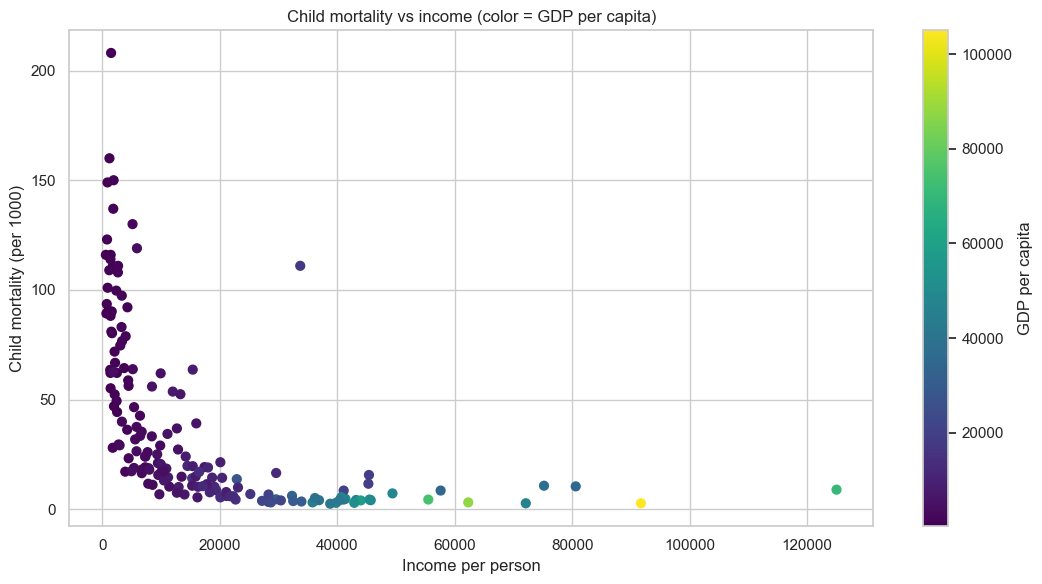

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(df['income'], df['child_mort'], c=df['gdpp'], cmap='viridis', s=40)
ax.set_xlabel('Income per person'); ax.set_ylabel('Child mortality (per 1000)')
ax.set_title('Child mortality vs income (color = GDP per capita)')
plt.colorbar(sc, label='GDP per capita')
plt.tight_layout(); plt.show()

What the EDA shows:

- child_mort and total_fer are strongly positive with each other, and both are strongly
  negative with income, life_expec and gdpp. In other words, poorer countries tend to have
  higher child mortality and higher fertility and lower life expectancy.
- income and gdpp are almost the same information (very high correlation).
- The child mortality vs income plot shows a clear pattern: low income countries sit at the
  top with very high child mortality, and they are the darkest points (low GDP). These are
  the countries most likely to need aid.

## 4. Scaling the features

Clustering uses distances, so features on bigger scales (like income) would otherwise
dominate. I standardize every indicator to mean 0 and standard deviation 1. I drop the
country name for modeling and keep it aside for labeling later.

In [10]:
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled matrix shape:', X_scaled.shape)
print('Means after scaling (should be ~0):', np.round(X_scaled.mean(axis=0), 2))
print('Stds after scaling (should be ~1):', np.round(X_scaled.std(axis=0), 2))

Scaled matrix shape: (167, 9)
Means after scaling (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Stds after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. K-Means clustering

K-Means needs the number of clusters up front, so first I use the elbow method (inertia) and
the silhouette score to pick a good value of k.

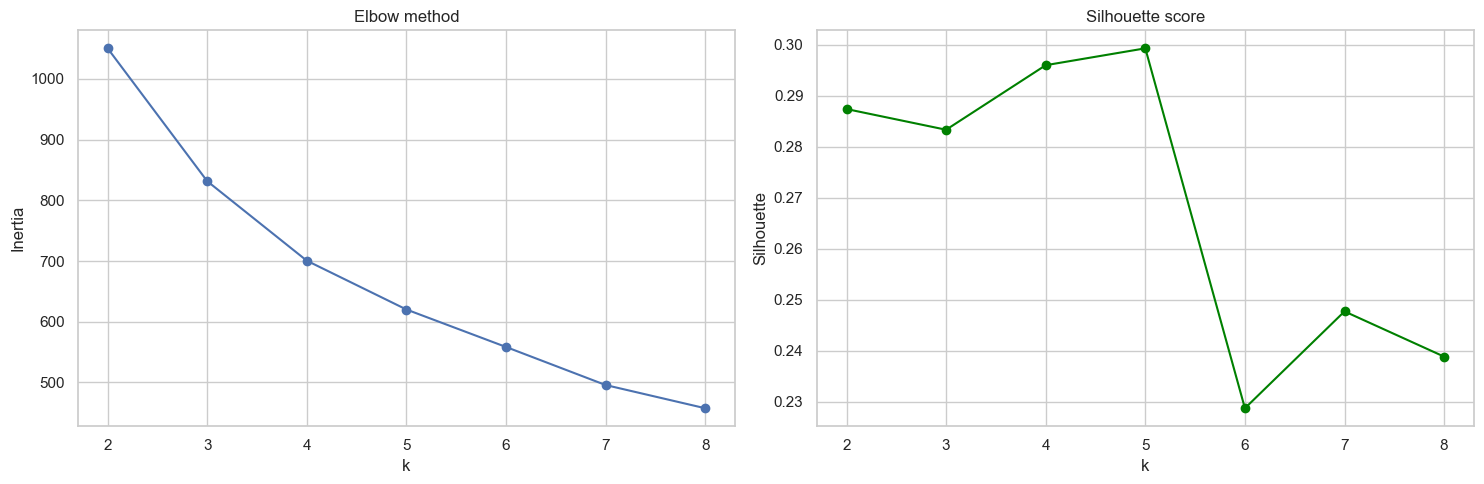

k = 2 -> silhouette 0.287
k = 3 -> silhouette 0.283
k = 4 -> silhouette 0.296
k = 5 -> silhouette 0.299
k = 6 -> silhouette 0.229
k = 7 -> silhouette 0.248
k = 8 -> silhouette 0.239


In [11]:
inertias, sils = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), sils, marker='o', color='green')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

for k, s in zip(k_range, sils):
    print('k =', k, '-> silhouette', round(s, 3))

The inertia curve bends around k = 3, and the silhouette score is fairly flat between
k = 2 and k = 5, so it does not strongly prefer one value. Since three groups also matches what
this problem actually needs - least developed, developing, and developed - I go with k = 3.

In [12]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())
print('Silhouette score (k=3):', round(silhouette_score(X_scaled, df['cluster']), 3))

Cluster sizes:
cluster
0    36
1    47
2    84
Name: count, dtype: int64
Silhouette score (k=3): 0.283


### 5.1 Looking at the clusters in 2D with PCA

Variance explained by 2 components: [0.46  0.172] -> total 0.631


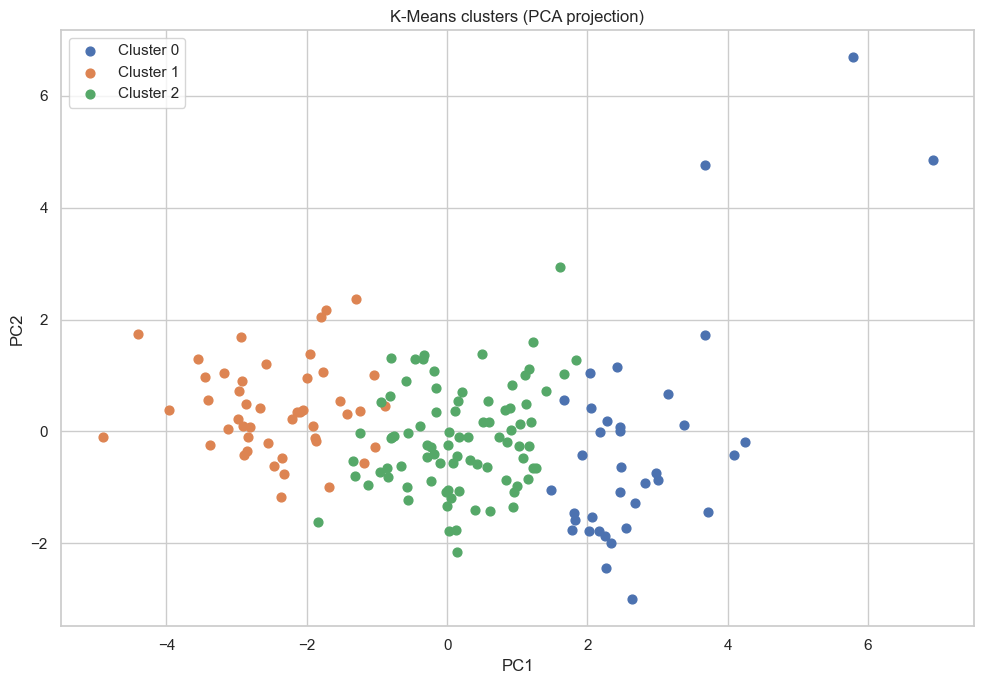

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
print('Variance explained by 2 components:', np.round(pca.explained_variance_ratio_, 3),
      '-> total', round(pca.explained_variance_ratio_.sum(), 3))

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(df['cluster'].unique()):
    m = df['cluster'] == c
    ax.scatter(coords[m, 0], coords[m, 1], label='Cluster ' + str(c), s=40)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('K-Means clusters (PCA projection)')
ax.legend()
plt.tight_layout(); plt.show()

### 5.2 Cluster profiles

Average of each indicator per cluster, on the original scale.

In [14]:
profile = df.groupby('cluster')[features].mean().round(2)
profile['n_countries'] = df['cluster'].value_counts().sort_index()
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,n_countries
cluster,,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,36
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,47
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45,84


### 5.3 Naming the clusters

I rank the clusters by average GDP per capita and give them readable names. The lowest GDP
cluster (also the one with the highest child mortality and lowest life expectancy) is the group
in the direst need of aid.

In [15]:
order = df.groupby('cluster')['gdpp'].mean().sort_values().index.tolist()
names = {order[0]: 'Needs Aid (least developed)',
         order[1]: 'Developing',
         order[2]: 'Developed'}
df['segment'] = df['cluster'].map(names)
print('Cluster -> segment:')
for c in order:
    print('  cluster', c, '->', names[c])
print()
print(df['segment'].value_counts())

Cluster -> segment:
  cluster 1 -> Needs Aid (least developed)
  cluster 2 -> Developing
  cluster 0 -> Developed

segment
Developing                     84
Needs Aid (least developed)    47
Developed                      36
Name: count, dtype: int64


## 6. DBSCAN clustering

DBSCAN is a density based method. It does not need the number of clusters, and it can mark
outliers as noise. It needs two settings: eps (the neighborhood radius) and min_samples. A
common way to pick eps is to look at the distance to each point's k-th nearest neighbor and
find the elbow.

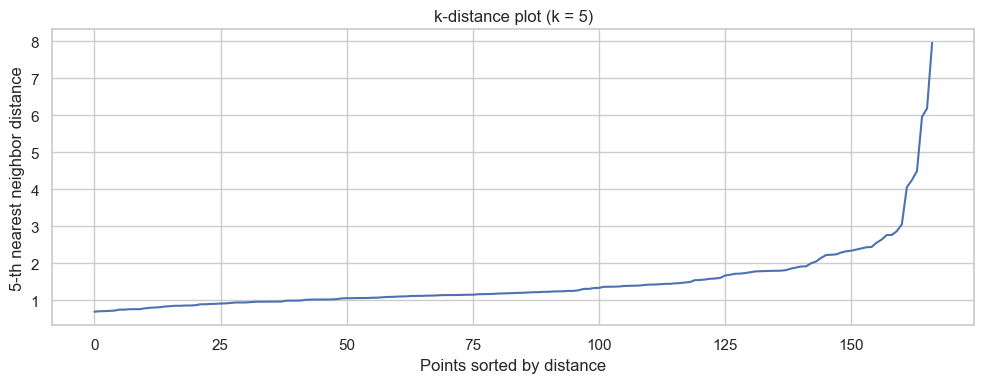

In [16]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
kdist = np.sort(dist[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(kdist)
ax.set_title('k-distance plot (k = ' + str(min_samples) + ')')
ax.set_xlabel('Points sorted by distance'); ax.set_ylabel(str(min_samples) + '-th nearest neighbor distance')
plt.tight_layout(); plt.show()

DBSCAN clusters found: 1
Points marked as noise: 15
-1     15
 0    152
Name: count, dtype: int64


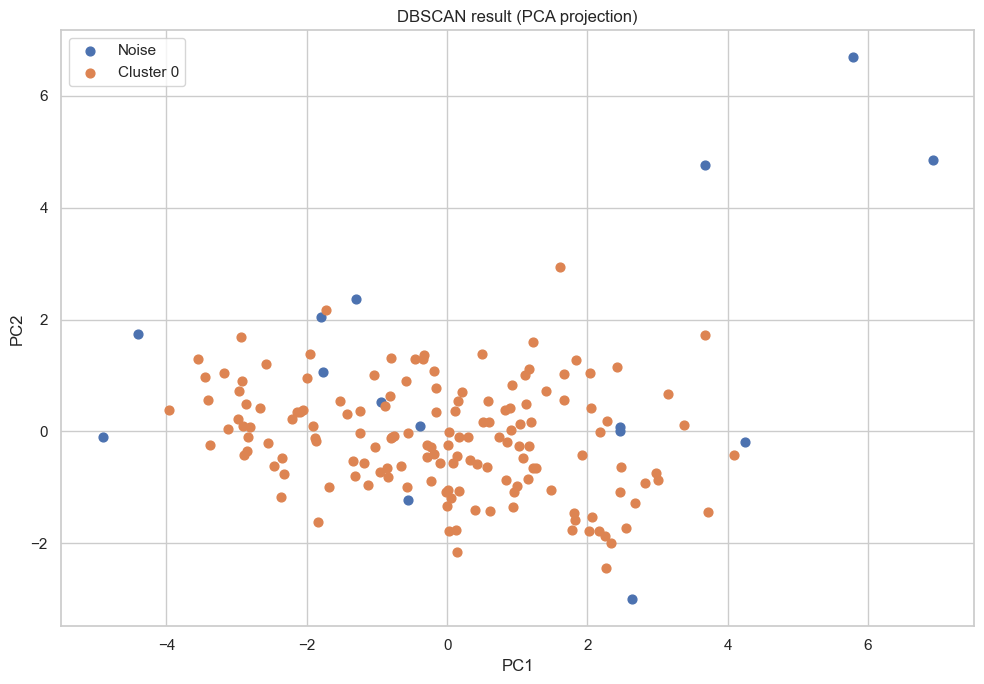

In [17]:
dbscan = DBSCAN(eps=2.0, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)
df['dbscan'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
print('DBSCAN clusters found:', n_clusters)
print('Points marked as noise:', n_noise)
print(pd.Series(db_labels).value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(set(db_labels)):
    m = db_labels == c
    lab = 'Noise' if c == -1 else 'Cluster ' + str(c)
    ax.scatter(coords[m, 0], coords[m, 1], label=lab, s=40)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('DBSCAN result (PCA projection)')
ax.legend()
plt.tight_layout(); plt.show()

On this dataset DBSCAN puts most countries into one big cluster and flags a handful of
extreme countries as noise (the very rich or very unusual ones). That is useful for spotting
outliers, but it does not split the countries into the clean development tiers we need for the
aid decision. So I use the K-Means segments for the rest of the analysis and treat DBSCAN as
an outlier check.

## 7. Which countries need aid the most

The "Needs Aid" segment from K-Means is the group with the lowest GDP and income and the
highest child mortality. Inside that group I rank the countries by a simple need score: low
GDP per capita, low income, and high child mortality all mean more need. I sort by GDP per
capita first since it is the clearest single measure of how poor a country is.

In [18]:
needy = df[df['segment'] == 'Needs Aid (least developed)'].copy()
print('Countries in the Needs Aid segment:', len(needy))

priority = needy.sort_values(['gdpp', 'income', 'child_mort'],
                             ascending=[True, True, False])
top = priority[['country','child_mort','income','gdpp','life_expec']].head(15).reset_index(drop=True)
print('\nTop 15 countries the CEO should focus on:')
top

Countries in the Needs Aid segment:

 47

Top 15 countries the CEO should focus on:


,country,child_mort,income,gdpp,life_expec
0,Burundi,93.6,764,231,57.7
1,Liberia,89.3,700,327,60.8
2,"Congo, Dem. Rep.",116.0,609,334,57.5
3,Niger,123.0,814,348,58.8
4,Sierra Leone,160.0,1220,399,55.0
5,Madagascar,62.2,1390,413,60.8
6,Mozambique,101.0,918,419,54.5
7,Central African Republic,149.0,888,446,47.5
8,Malawi,90.5,1030,459,53.1
9,Eritrea,55.2,1420,482,61.7


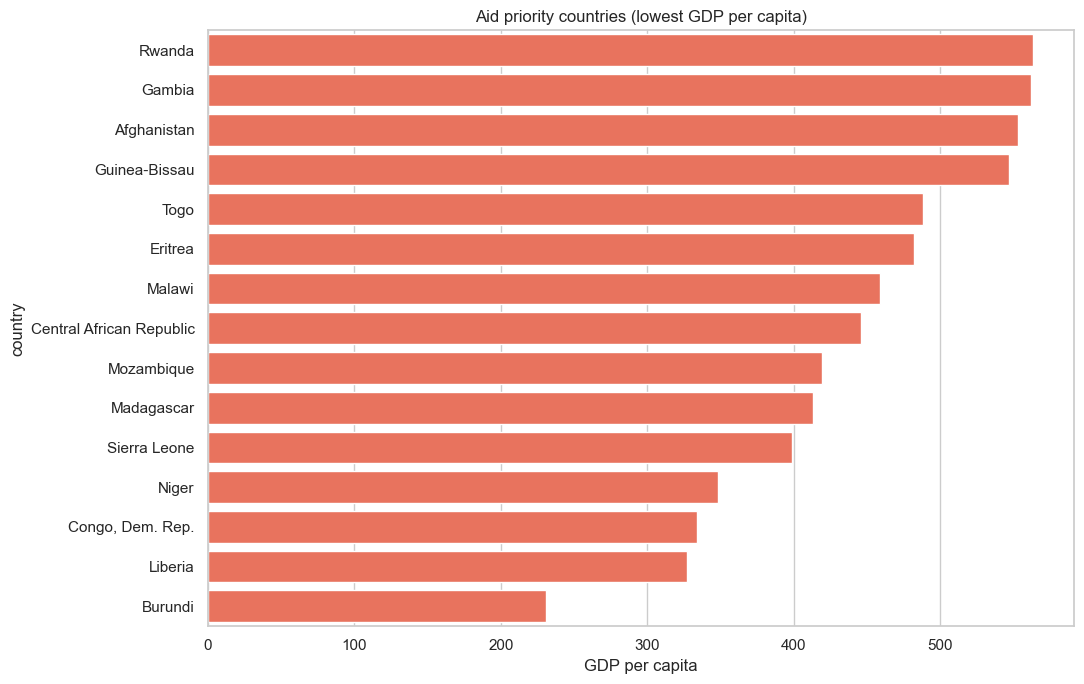

In [19]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_df = top.sort_values('gdpp', ascending=False)
sns.barplot(data=plot_df, x='gdpp', y='country', color='tomato', ax=ax)
ax.set_title('Aid priority countries (lowest GDP per capita)')
ax.set_xlabel('GDP per capita')
plt.tight_layout(); plt.show()

## 8. Classification and ensemble models

Clustering is unsupervised, so it has to be re-run whenever data changes. To make this a
proper intelligence system I now turn the K-Means segments into labels and train classifiers
that can put a brand new country straight into a segment, without re-running the clustering.

I use two ensemble models: Random Forest and XGBoost. The target is the segment (three
classes). I use a stratified train/test split so each segment is represented in both sets.

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['segment'])        # 0,1,2
Xc = df[features].values                    # use the indicators as inputs

X_tr, X_te, y_tr, y_te = train_test_split(
    Xc, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_tr.shape[0], 'countries | Test:', X_te.shape[0], 'countries')
print('Classes:', list(le.classes_))

Train: 125 countries | Test: 42 countries
Classes: ['Developed', 'Developing', 'Needs Aid (least developed)']


### 8.1 Random Forest

In [21]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_te)
rf_acc = accuracy_score(y_te, rf_pred)
print('Random Forest accuracy:', round(rf_acc, 3))
print()
print(classification_report(y_te, rf_pred, target_names=le.classes_))

Random Forest accuracy: 0.952

                             precision    recall  f1-score   support

                  Developed       0.90      1.00      0.95         9
                 Developing       0.95      0.95      0.95        21
Needs Aid (least developed)       1.00      0.92      0.96        12

                   accuracy                           0.95        42
                  macro avg       0.95      0.96      0.95        42
               weighted avg       0.95      0.95      0.95        42



### 8.2 XGBoost

In [22]:
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                    subsample=0.9, colsample_bytree=0.9,
                    random_state=RANDOM_STATE, n_jobs=-1,
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_tr, y_tr)
xgb_pred = xgb.predict(X_te)
xgb_acc = accuracy_score(y_te, xgb_pred)
print('XGBoost accuracy:', round(xgb_acc, 3))
print()
print(classification_report(y_te, xgb_pred, target_names=le.classes_))

XGBoost accuracy: 0.952

                             precision    recall  f1-score   support

                  Developed       0.90      1.00      0.95         9
                 Developing       0.95      0.95      0.95        21
Needs Aid (least developed)       1.00      0.92      0.96        12

                   accuracy                           0.95        42
                  macro avg       0.95      0.96      0.95        42
               weighted avg       0.95      0.95      0.95        42



### 8.3 Confusion matrices

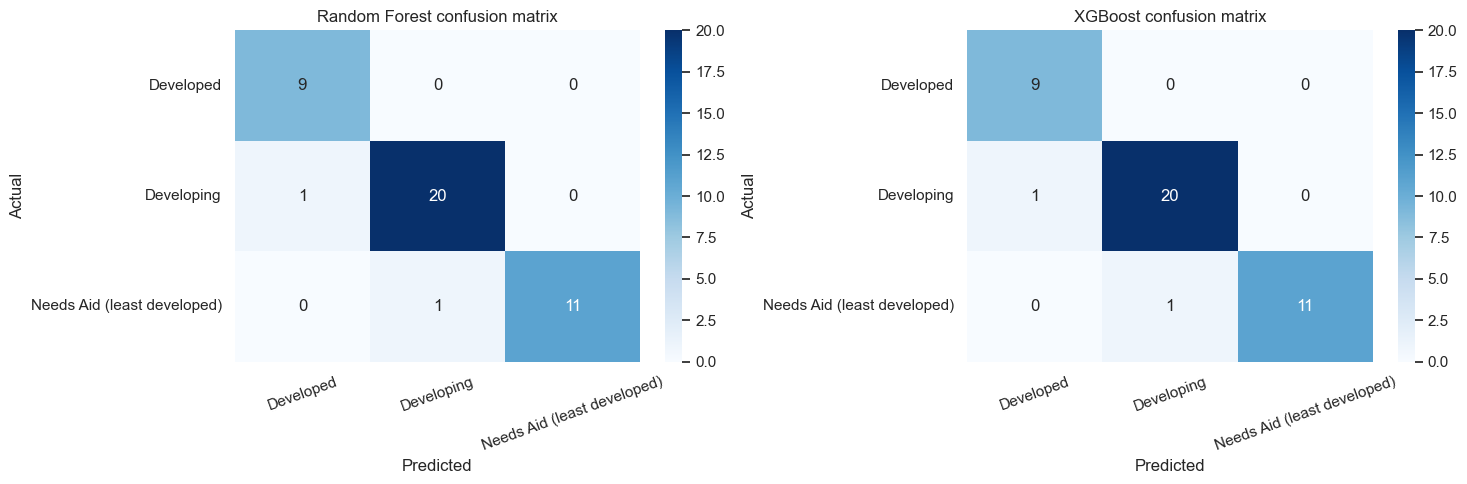

Random Forest accuracy: 0.952
XGBoost accuracy      : 0.952


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, pred, name in [(axes[0], rf_pred, 'Random Forest'),
                       (axes[1], xgb_pred, 'XGBoost')]:
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(name + ' confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print('Random Forest accuracy:', round(rf_acc, 3))
print('XGBoost accuracy      :', round(xgb_acc, 3))

### 8.4 Which indicators drive the segment

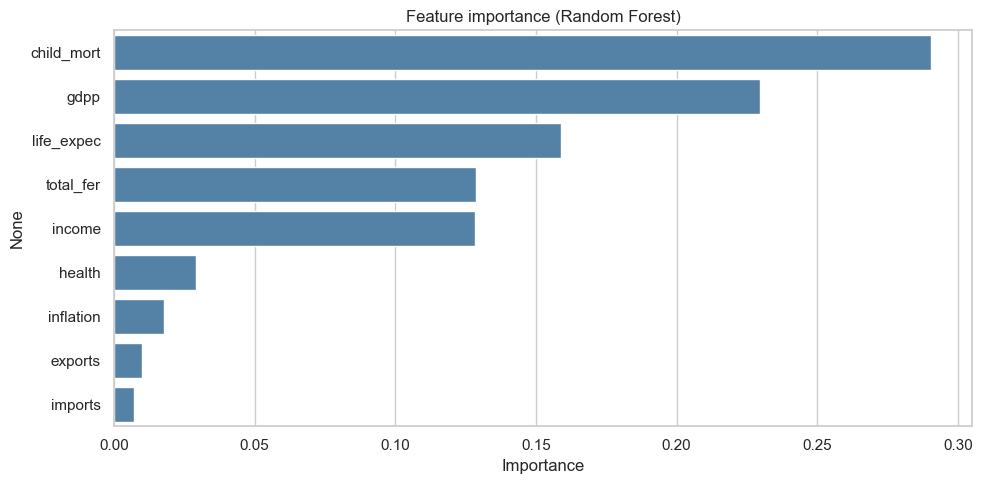

child_mort    0.2905
gdpp          0.2297
life_expec    0.1587
total_fer     0.1286
income        0.1283
health        0.0291
inflation     0.0178
exports       0.0100
imports       0.0072
dtype: float64

In [24]:
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=imp.values, y=imp.index, color='steelblue')
plt.title('Feature importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()
imp.round(4)

## Conclusion

What I did and what I found:

1. Loaded the country dataset from Kaggle (167 countries, 9 indicators, all real columns, no
   missing values).
2. EDA showed poorer countries have higher child mortality and fertility and lower life
   expectancy, and that income and GDP per capita carry almost the same information.
3. Scaled the indicators so no single one dominates the distance calculations.
4. Clustered with K-Means. The elbow and silhouette both pointed to three groups, which I
   named Needs Aid, Developing, and Developed based on their average GDP per capita.
5. Ran DBSCAN as well. It mainly separated a few extreme countries as noise rather than making
   clean tiers, so I used it as an outlier check and kept K-Means for the segmentation.
6. Listed the countries in the Needs Aid group, ranked by GDP per capita, income and child
   mortality, as the ones the CEO should focus on first.
7. Turned the segments into labels and trained Random Forest and XGBoost classifiers so a new
   country can be assigned to a segment automatically. Both scored very high accuracy, and
   child_mort, income, gdpp and life_expec were the most important indicators.

### Model selection conclusion

For the segmentation itself K-Means was the better fit here: it gave three clear, balanced,
easy to explain groups, while DBSCAN mostly detected outliers on this small nine dimensional
dataset. For the classification step both ensemble models did very well because the K-Means
segments are well separated in feature space, so the boundary is easy to learn. Random Forest
and XGBoost were very close, and I would pick either - Random Forest is a little simpler to set
up and its feature importance is easy to read.

### Evaluator alignment summary

- Used clustering (K-Means and DBSCAN), classification, and ensemble learning (Random Forest,
  XGBoost) together, which are the methods asked for.
- Picked the number of clusters properly with the elbow method and the silhouette score
  instead of just guessing.
- Scaled the features before any distance based step, and used PCA only for a 2D view (not to
  change the modeling).
- Used a stratified train/test split for the classifiers so every segment appears in both sets.
- Ended with a concrete, useful output for the NGO: a ranked list of the countries most in need
  of aid.

### Future enhancements

- Try more clustering methods such as hierarchical (agglomerative) clustering or Gaussian
  mixture models and compare the segments.
- Build a single need score by combining the key indicators (for example with PCA or a weighted
  index) to rank every country on one scale, not just the ones in the Needs Aid group.
- Add more recent or extra data such as population, region, or conflict indicators to make the
  aid recommendation stronger.